<a href="https://colab.research.google.com/github/BekaShay/FirstRepositoryChatyfi/blob/main/V2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_20newsgroups

train_data = fetch_20newsgroups(subset='train', remove=())  # можно ещё remove=('headers','footers','quotes') для усложнения
test_data  = fetch_20newsgroups(subset='test',  remove=())

X_train_texts = train_data.data
y_train       = train_data.target

X_test_texts  = test_data.data
y_test        = test_data.target

print(len(X_train_texts), len(X_test_texts))
print(train_data.target_names)  # 20 классов


11314 7532
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline, FeatureUnion

# Light Model

In [3]:
N_LIGHT = int(1 * len(X_train_texts))

X_train_L, y_train_L = resample(
    X_train_texts, y_train,
    n_samples=N_LIGHT,
    replace=False,
    random_state=42,
    stratify=y_train
)

pipe_L = Pipeline([
    ("vect", CountVectorizer(
        max_features=2000,
        ngram_range=(1, 1),
        lowercase=True
    )),
    ("clf", MultinomialNB(alpha=2.0))
])

pipe_L.fit(X_train_L, y_train_L)
y_pred_L = pipe_L.predict(X_test_texts)

acc_L = accuracy_score(y_test, y_pred_L)
print("Light accuracy:", acc_L)
print(classification_report(y_test, y_pred_L))


Light accuracy: 0.6682156133828996
              precision    recall  f1-score   support

           0       0.57      0.65      0.61       319
           1       0.45      0.68      0.54       389
           2       0.33      0.00      0.01       394
           3       0.45      0.59      0.51       392
           4       0.56      0.69      0.61       385
           5       0.73      0.61      0.66       395
           6       0.67      0.88      0.76       390
           7       0.68      0.80      0.73       396
           8       0.64      0.89      0.74       398
           9       0.69      0.83      0.75       397
          10       0.94      0.69      0.79       399
          11       0.91      0.75      0.82       396
          12       0.57      0.61      0.59       393
          13       0.80      0.61      0.69       396
          14       0.81      0.77      0.79       394
          15       0.84      0.78      0.81       398
          16       0.67      0.79      0.73   

# Medium Model

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

pipe_M_bow = Pipeline([
    ("bow", CountVectorizer(
        max_features=N_LIGHT,
        ngram_range=(1, 2),
        lowercase=True
    )),
    ("clf", LinearSVC(C=1.0))
])

pipe_M_bow.fit(X_train_texts, y_train)
y_pred_M_bow = pipe_M_bow.predict(X_test_texts)

from sklearn.metrics import accuracy_score, classification_report
acc_M_bow = accuracy_score(y_test, y_pred_M_bow)
print("Medium (BoW+SVM) accuracy:", acc_M_bow)
print(classification_report(y_test, y_pred_M_bow))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Medium (BoW+SVM) accuracy: 0.7480084970791291
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       319
           1       0.60      0.65      0.62       389
           2       0.68      0.66      0.67       394
           3       0.57      0.62      0.60       392
           4       0.72      0.72      0.72       385
           5       0.77      0.67      0.72       395
           6       0.79      0.86      0.82       390
           7       0.78      0.77      0.77       396
           8       0.85      0.89      0.87       398
           9       0.84      0.82      0.83       397
          10       0.92      0.92      0.92       399
          11       0.86      0.87      0.87       396
          12       0.62      0.60      0.61       393
          13       0.74      0.73      0.74       396
          14       0.86      0.86      0.86       394
          15       0.81      0.91      0.86       398
          16       0.70      0.82  

# High Model

In [5]:
word_vect = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    lowercase=True
)

char_vect = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=30000,
    sublinear_tf=True
)

pipe_H = Pipeline([
    ("features", FeatureUnion([
        ("word", word_vect),
        ("char", char_vect),
    ])),
    ("clf", LinearSVC(C=2.0))
], verbose=True)

pipe_H.fit(X_train_texts, y_train)
y_pred_H = pipe_H.predict(X_test_texts)

acc_H = accuracy_score(y_test, y_pred_H)
print("High accuracy:", acc_H)
print(classification_report(y_test, y_pred_H))

[Pipeline] .......... (step 1 of 2) Processing features, total=  58.3s
[Pipeline] ............... (step 2 of 2) Processing clf, total=  36.1s
High accuracy: 0.8542219861922464
              precision    recall  f1-score   support

           0       0.78      0.77      0.78       319
           1       0.77      0.80      0.79       389
           2       0.79      0.76      0.78       394
           3       0.73      0.76      0.75       392
           4       0.83      0.85      0.84       385
           5       0.90      0.80      0.85       395
           6       0.85      0.92      0.89       390
           7       0.90      0.88      0.89       396
           8       0.95      0.94      0.94       398
           9       0.92      0.95      0.93       397
          10       0.94      0.97      0.96       399
          11       0.94      0.94      0.94       396
          12       0.78      0.79      0.79       393
          13       0.90      0.88      0.89       396
          14 

In [6]:
print(f"Light  accuracy: {acc_L:.4f}")
print(f"Medium accuracy: {acc_M_bow:.4f}")
print(f"High   accuracy: {acc_H:.4f}")

Light  accuracy: 0.6682
Medium accuracy: 0.7480
High   accuracy: 0.8542


# Cascade

VAL базовые точности:
  Light : 0.6710
  Medium: 0.7464
  High  : 0.8593
  cost_L: 0.000178 сек, cost_M: 0.000350 сек, cost_H: 0.003418 сек

Всего комбинаций порогов: 10000

ВАРИАНТ A (максимум accuracy при ограничении по cost):
qL      81.000000
qM      42.000000
t_L      1.000000
t_M      1.043830
acc      0.845725
cost     0.001705
pL       0.190122
pM       0.404673
pH       0.405204
Name: 8041, dtype: float64


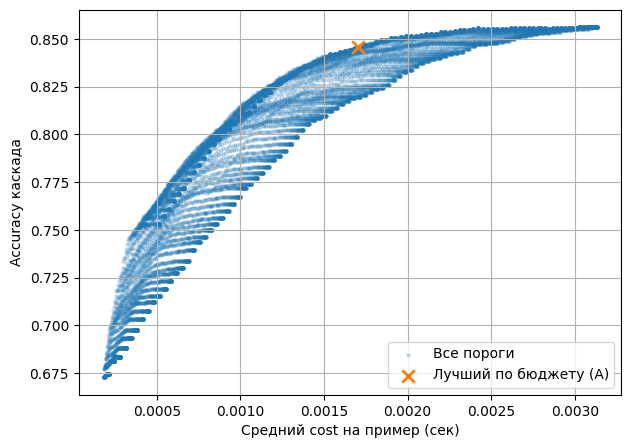


FINAL базовые точности:
  Light : 0.6654
  Medium: 0.7496
  High  : 0.8492
  cost_L: 0.000169 сек, cost_M: 0.000319 сек, cost_H: 0.003321 сек

ИТОГИ КАСКАДА L->M->H НА FINAL (только вариант A):
  Accuracy каскада      : 0.8386
  Средний cost каскада  : 0.001601 сек
  Доли обращений каскада: L=19.99%, M=40.81%, H=39.19%

Для сравнения (FINAL):
  Accuracy Medium only  : 0.7496, cost=0.000319
  Accuracy High only    : 0.8492, cost=0.003321


In [21]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ======================================================
# 1. Вспомогательные функции
# ======================================================

def get_preds_dec_cost(pipe, X):
    t0 = time.time()
    y_pred = pipe.predict(X)
    t1 = time.time()
    cost = (t1 - t0) / len(X)

    if hasattr(pipe.steps[-1][1], 'decision_function'):
        dec = pipe.decision_function(X)
    elif hasattr(pipe.steps[-1][1], 'predict_proba'):
        dec = pipe.predict_proba(X)
    else:
        raise AttributeError(
            f"Final estimator {type(pipe.steps[-1][1])} has neither decision_function nor predict_proba."
        )
    return y_pred, dec, cost


def margin_conf(dec):
    dec = np.asarray(dec)
    if dec.ndim == 1:
        return np.abs(dec)

    scores_sorted = np.sort(dec, axis=1)
    return scores_sorted[:, -1] - scores_sorted[:, -2]


def eval_cascade_LMH(conf_L, conf_M,
                     y_L, y_M, y_H, y_true,
                     cost_L, cost_M, cost_H,
                     t_L, t_M):

    conf_L = np.asarray(conf_L)
    conf_M = np.asarray(conf_M)
    y_L = np.asarray(y_L)
    y_M = np.asarray(y_M)
    y_H = np.asarray(y_H)
    y_true = np.asarray(y_true)

    use_L = conf_L >= t_L
    use_M = (~use_L) & (conf_M >= t_M)
    use_H = (~use_L) & (~use_M)

    preds = np.empty_like(y_true)
    preds[use_L] = y_L[use_L]
    preds[use_M] = y_M[use_M]
    preds[use_H] = y_H[use_H]

    acc = accuracy_score(y_true, preds)

    p_L = use_L.mean()
    p_M = use_M.mean()
    p_H = use_H.mean()

    avg_cost = cost_L + p_M * cost_M + p_H * cost_H

    return acc, avg_cost, p_L, p_M, p_H


# ======================================================
# 2. Делим TEST на VAL и FINAL
# ======================================================

X_val, X_final, y_val, y_final = train_test_split(
    X_test_texts, y_test,
    test_size=0.5,
    random_state=42,
    stratify=y_test
)

X_val   = list(X_val)
X_final = list(X_final)
y_val   = np.array(y_val)
y_final = np.array(y_final)

# ======================================================
# 3. Предсказания и cost на VAL
# ======================================================

y_L_val, dec_L_val, cost_L_val = get_preds_dec_cost(pipe_L,     X_val)
y_M_val, dec_M_val, cost_M_val = get_preds_dec_cost(pipe_M_bow, X_val)
y_H_val, dec_H_val, cost_H_val = get_preds_dec_cost(pipe_H,    X_val)

conf_L_val = margin_conf(dec_L_val)
conf_M_val = margin_conf(dec_M_val)

print("VAL базовые точности:")
print(f"  Light : {accuracy_score(y_val, y_L_val):.4f}")
print(f"  Medium: {accuracy_score(y_val, y_M_val):.4f}")
print(f"  High  : {accuracy_score(y_val, y_H_val):.4f}")
print(f"  cost_L: {cost_L_val:.6f} сек, cost_M: {cost_M_val:.6f} сек, cost_H: {cost_H_val:.6f} сек")

# ======================================================
# 4. Полный перебор порогов по квантилям 1..100 (для VAL)
# ======================================================

results = []

for qL in range(1, 101):
    t_L = np.percentile(conf_L_val, qL)
    for qM in range(1, 101):
        t_M = np.percentile(conf_M_val, qM)

        acc_val, cost_val, pL_val, pM_val, pH_val = eval_cascade_LMH(
            conf_L_val, conf_M_val,
            y_L_val, y_M_val, y_H_val, y_val,
            cost_L_val, cost_M_val, cost_H_val,
            t_L, t_M
        )

        results.append({
            "qL": qL,
            "qM": qM,
            "t_L": t_L,
            "t_M": t_M,
            "acc": acc_val,
            "cost": cost_val,
            "pL": pL_val,
            "pM": pM_val,
            "pH": pH_val,
        })

df = pd.DataFrame(results)
print("\nВсего комбинаций порогов:", len(df))  # должно быть 10000

# ======================================================
# 5. Вариант A: максимум accuracy при ограничении cost <= alpha * cost_H
# ======================================================

alpha = 0.5

budget = alpha * cost_H_val

df_feasible = df[df["cost"] <= budget]

if len(df_feasible) == 0:
    print(f"\nВАРИАНТ A: нет точек, удовлетворяющих cost <= {alpha:.2f} * cost_H "
          f"(budget={budget:.6f}). Попробуй увеличить alpha.")
    best_A = None
else:
    best_A = df_feasible.loc[df_feasible["acc"].idxmax()]
    print("\nВАРИАНТ A (максимум accuracy при ограничении по cost):")
    print(best_A[["qL", "qM", "t_L", "t_M", "acc", "cost", "pL", "pM", "pH"]])


# ======================================================
# 6. Визуализация trade-off accuracy vs cost (только вариант A)
# ======================================================

plt.figure(figsize=(7, 5))
plt.scatter(df["cost"], df["acc"], s=5, alpha=0.2, label="Все пороги")

if best_A is not None:
    plt.scatter(best_A["cost"], best_A["acc"],
                s=80, marker="x", linewidths=2,
                label="Лучший по бюджету (A)")

plt.xlabel("Средний cost на пример (сек)")
plt.ylabel("Accuracy каскада")
plt.title("")
plt.legend()
plt.grid(True)
plt.show()


# ======================================================
# 7. Оценка выбранного каскада на FINAL
# ======================================================

y_L_final, dec_L_final, cost_L_final = get_preds_dec_cost(pipe_L,     X_final)
y_M_final, dec_M_final, cost_M_final = get_preds_dec_cost(pipe_M_bow, X_final)
y_H_final, dec_H_final, cost_H_final = get_preds_dec_cost(pipe_H,      X_final)

conf_L_final = margin_conf(dec_L_final)
conf_M_final = margin_conf(dec_M_final)
conf_H_final = margin_conf(dec_H_final) # New: Added to capture High model confidence

print("\nFINAL базовые точности:")
print(f"  Light : {accuracy_score(y_final, y_L_final):.4f}")
print(f"  Medium: {accuracy_score(y_final, y_M_final):.4f}")
print(f"  High  : {accuracy_score(y_final, y_H_final):.4f}")
print(f"  cost_L: {cost_L_final:.6f} сек, cost_M: {cost_M_final:.6f} сек, cost_H: {cost_H_final:.6f} сек")


# --- теперь только вариант A ---
if best_A is None:
    print("\nКаскад не найден в рамках бюджета. Увеличьте alpha.")
else:
    t_L_best = best_A["t_L"]
    t_M_best = best_A["t_M"]

    acc_fin, cost_fin, pL_fin, pM_fin, pH_fin = eval_cascade_LMH(
        conf_L_final, conf_M_final,
        y_L_final, y_M_final, y_H_final, y_final,
        cost_L_final, cost_M_final, cost_H_final,
        t_L_best, t_M_best
    )

    print(f"\nИТОГИ КАСКАДА L->M->H НА FINAL (только вариант A):")
    print(f"  Accuracy каскада      : {acc_fin:.4f}")
    print(f"  Средний cost каскада  : {cost_fin:.6f} сек")
    print(f"  Доли обращений каскада: L={pL_fin:.2%}, M={pM_fin:.2%}, H={pH_fin:.2%}")

    print("\nДля сравнения (FINAL):")
    print(f"  Accuracy Medium only  : {accuracy_score(y_final, y_M_final):.4f}, cost={cost_M_final:.6f}")
    print(f"  Accuracy High only    : {accuracy_score(y_final, y_H_final):.4f}, cost={cost_H_final:.6f}")


alpha=0.1: нет точек с cost <= 0.000359

Лучшие каскады для разных alpha (на VAL):
   alpha    budget    qL    qM       t_L       t_M   acc_val  cost_val  \
0    0.2  0.000719  37.0   3.0  0.995745  0.046132  0.750929  0.000718   
1    0.3  0.001078  56.0  13.0  0.999989  0.234943  0.790228  0.001077   
2    0.4  0.001438  58.0  26.0  0.999996  0.528599  0.818109  0.001435   
3    0.5  0.001797  66.0  35.0  1.000000  0.788297  0.836166  0.001766   
4    0.6  0.002156  76.0  45.0  1.000000  1.158849  0.846787  0.002155   
5    0.7  0.002516  87.0  53.0  1.000000  1.482630  0.851832  0.002507   
6    0.8  0.002875  87.0  65.0  1.000000  2.114996  0.855550  0.002862   
7    0.9  0.003234  87.0  65.0  1.000000  2.114996  0.855550  0.002862   
8    1.0  0.003594  87.0  89.0  1.000000  4.657457  0.856081  0.003483   

     pL_val    pM_val    pH_val  
0  0.629846  0.347584  0.022570  
1  0.439989  0.449814  0.110196  
2  0.420074  0.359267  0.220659  
3  0.340149  0.345459  0.314392  
4  0.2

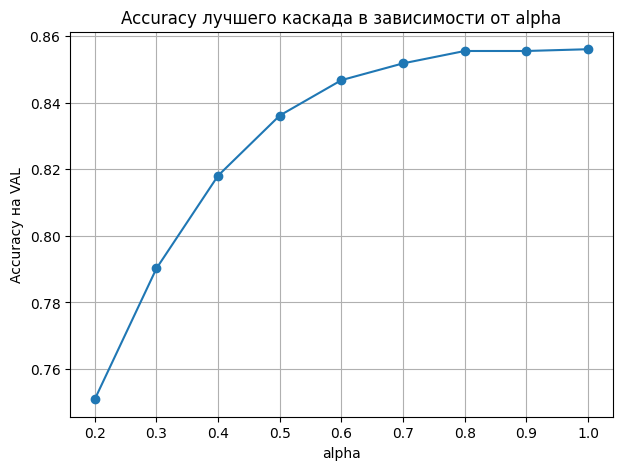

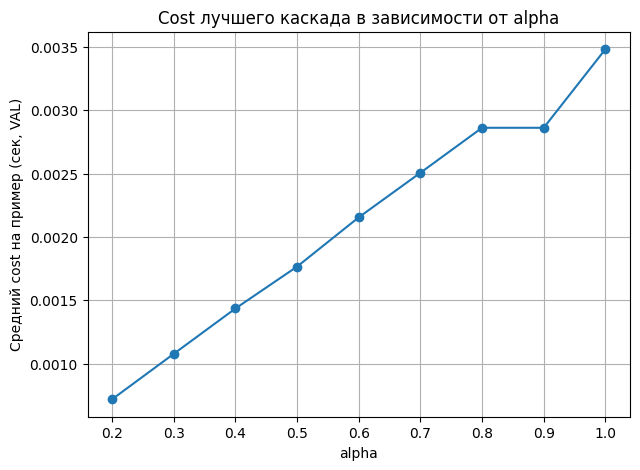

In [8]:
# ======================================================
# 5. Поиск лучшего каскада для разных alpha (0.1 ... 1.0)
# ======================================================

alpha_list = np.arange(0.1, 1.01, 0.1)

rows = []
for alpha in alpha_list:
    budget = alpha * cost_H_val
    df_feasible = df[df["cost"] <= budget]

    if len(df_feasible) == 0:
        print(f"alpha={alpha:.1f}: нет точек с cost <= {budget:.6f}")
        continue

    best = df_feasible.loc[df_feasible["acc"].idxmax()]

    rows.append({
        "alpha": alpha,
        "budget": budget,
        "qL": best["qL"],
        "qM": best["qM"],
        "t_L": best["t_L"],
        "t_M": best["t_M"],
        "acc_val": best["acc"],
        "cost_val": best["cost"],
        "pL_val": best["pL"],
        "pM_val": best["pM"],
        "pH_val": best["pH"],
    })

df_alpha = pd.DataFrame(rows)
print("\nЛучшие каскады для разных alpha (на VAL):")
print(df_alpha)

# (опционально) если хочешь красиво отформатировать
print("\nКраткая таблица alpha / acc / cost / доли моделей:")
for _, r in df_alpha.iterrows():
    print(f"alpha={r['alpha']:.1f} | acc={r['acc_val']:.4f} | "
          f"cost={r['cost_val']:.6f} | "
          f"L={r['pL_val']:.1%}, M={r['pM_val']:.1%}, H={r['pH_val']:.1%}")
# ======================================================
# 6. Графики: accuracy(alpha) и cost(alpha)
# ======================================================

plt.figure(figsize=(7, 5))
plt.plot(df_alpha["alpha"], df_alpha["acc_val"], marker="o")
plt.xlabel("alpha")
plt.ylabel("Accuracy на VAL")
plt.title("Accuracy лучшего каскада в зависимости от alpha")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df_alpha["alpha"], df_alpha["cost_val"], marker="o")
plt.xlabel("alpha")
plt.ylabel("Средний cost на пример (сек, VAL)")
plt.title("Cost лучшего каскада в зависимости от alpha")
plt.grid(True)
plt.show()


In [9]:
# ======================================================
# 1. Сбор лучших порогов по alpha на VAL
# ======================================================

alpha_list = np.arange(0.1, 1.01, 0.1)

rows_val = []

for alpha in alpha_list:
    budget = alpha * cost_H_val
    df_feasible = df[df["cost"] <= budget]

    if len(df_feasible) == 0:
        print(f"alpha={alpha:.1f}: нет точек в бюджете")
        continue

    best = df_feasible.loc[df_feasible["acc"].idxmax()]

    rows_val.append({
        "alpha": alpha,
        "t_L": best["t_L"],
        "t_M": best["t_M"],
        "qL": best["qL"],
        "qM": best["qM"],
        "acc_val": best["acc"],
        "cost_val": best["cost"],
        "pL_val": best["pL"],
        "pM_val": best["pM"],
        "pH_val": best["pH"],
    })

df_alpha_val = pd.DataFrame(rows_val)

print("\nЛучшие пороги на VAL:")
print(df_alpha_val)


alpha=0.1: нет точек в бюджете

Лучшие пороги на VAL:
   alpha       t_L       t_M    qL    qM   acc_val  cost_val    pL_val  \
0    0.2  0.995745  0.046132  37.0   3.0  0.750929  0.000718  0.629846   
1    0.3  0.999989  0.234943  56.0  13.0  0.790228  0.001077  0.439989   
2    0.4  0.999996  0.528599  58.0  26.0  0.818109  0.001435  0.420074   
3    0.5  1.000000  0.788297  66.0  35.0  0.836166  0.001766  0.340149   
4    0.6  1.000000  1.158849  76.0  45.0  0.846787  0.002155  0.240042   
5    0.7  1.000000  1.482630  87.0  53.0  0.851832  0.002507  0.136484   
6    0.8  1.000000  2.114996  87.0  65.0  0.855550  0.002862  0.136484   
7    0.9  1.000000  2.114996  87.0  65.0  0.855550  0.002862  0.136484   
8    1.0  1.000000  4.657457  87.0  89.0  0.856081  0.003483  0.136484   

     pM_val    pH_val  
0  0.347584  0.022570  
1  0.449814  0.110196  
2  0.359267  0.220659  
3  0.345459  0.314392  
4  0.336166  0.423792  
5  0.342539  0.520977  
6  0.230218  0.633298  
7  0.230218  

In [10]:
# ======================================================
# 2. Оценка этих порогов на FINAL
# ======================================================

results_final = []

for _, row in df_alpha_val.iterrows():
    alpha = row["alpha"]
    t_L = row["t_L"]
    t_M = row["t_M"]

    acc_f, cost_f, pL_f, pM_f, pH_f = eval_cascade_LMH(
        conf_L_final, conf_M_final,
        y_L_final, y_M_final, y_H_final, y_final,
        cost_L_final, cost_M_final, cost_H_final,
        t_L, t_M
    )

    results_final.append({
        "alpha": alpha,
        "acc_final": acc_f,
        "cost_final": cost_f,
        "pL_final": pL_f,
        "pM_final": pM_f,
        "pH_final": pH_f,
        "t_L": t_L,
        "t_M": t_M
    })

df_alpha_final = pd.DataFrame(results_final)

print("\nРезультаты каскадов на FINAL:")
print(df_alpha_final)



Результаты каскадов на FINAL:
   alpha  acc_final  cost_final  pL_final  pM_final  pH_final       t_L  \
0    0.2   0.743229    0.000487  0.638609  0.340414  0.020977  0.995745   
1    0.3   0.786511    0.000827  0.461763  0.422995  0.115242  0.999989   
2    0.4   0.813330    0.001138  0.436006  0.348115  0.215879  0.999996   
3    0.5   0.825279    0.001410  0.355815  0.346522  0.297663  1.000000   
4    0.6   0.839883    0.001784  0.251726  0.337493  0.410781  1.000000   
5    0.7   0.842539    0.002086  0.141795  0.358736  0.499469  1.000000   
6    0.8   0.845725    0.002423  0.141795  0.246681  0.611524  1.000000   
7    0.9   0.845725    0.002423  0.141795  0.246681  0.611524  1.000000   
8    1.0   0.847849    0.003056  0.141795  0.036644  0.821561  1.000000   

        t_M  
0  0.046132  
1  0.234943  
2  0.528599  
3  0.788297  
4  1.158849  
5  1.482630  
6  2.114996  
7  2.114996  
8  4.657457  


In [11]:
print("\nКраткая таблица результатов на FINAL:")
for _, r in df_alpha_final.iterrows():
    print(f"alpha={r['alpha']:.1f} | acc={r['acc_final']:.4f} | "
          f"cost={r['cost_final']:.6f} | "
          f"L={r['pL_final']:.1%}, M={r['pM_final']:.1%}, H={r['pH_final']:.1%}")



Краткая таблица результатов на FINAL:
alpha=0.2 | acc=0.7432 | cost=0.000487 | L=63.9%, M=34.0%, H=2.1%
alpha=0.3 | acc=0.7865 | cost=0.000827 | L=46.2%, M=42.3%, H=11.5%
alpha=0.4 | acc=0.8133 | cost=0.001138 | L=43.6%, M=34.8%, H=21.6%
alpha=0.5 | acc=0.8253 | cost=0.001410 | L=35.6%, M=34.7%, H=29.8%
alpha=0.6 | acc=0.8399 | cost=0.001784 | L=25.2%, M=33.7%, H=41.1%
alpha=0.7 | acc=0.8425 | cost=0.002086 | L=14.2%, M=35.9%, H=49.9%
alpha=0.8 | acc=0.8457 | cost=0.002423 | L=14.2%, M=24.7%, H=61.2%
alpha=0.9 | acc=0.8457 | cost=0.002423 | L=14.2%, M=24.7%, H=61.2%
alpha=1.0 | acc=0.8478 | cost=0.003056 | L=14.2%, M=3.7%, H=82.2%



Результаты по alpha:
    alpha  has_solution       t_L       t_M   acc_val  cost_val  acc_final  \
0     0.0         False       NaN       NaN       NaN       NaN        NaN   
1     0.1         False       NaN       NaN       NaN       NaN        NaN   
2     0.2          True  0.995745  0.046132  0.750929  0.000718   0.743229   
3     0.3          True  0.999989  0.234943  0.790228  0.001077   0.786511   
4     0.4          True  0.999996  0.528599  0.818109  0.001435   0.813330   
5     0.5          True  1.000000  0.788297  0.836166  0.001766   0.825279   
6     0.6          True  1.000000  1.158849  0.846787  0.002155   0.839883   
7     0.7          True  1.000000  1.482630  0.851832  0.002507   0.842539   
8     0.8          True  1.000000  2.114996  0.855550  0.002862   0.845725   
9     0.9          True  1.000000  2.114996  0.855550  0.002862   0.845725   
10    1.0          True  1.000000  4.657457  0.856081  0.003483   0.847849   

    cost_final  pL_final  pM_final  pH_fi

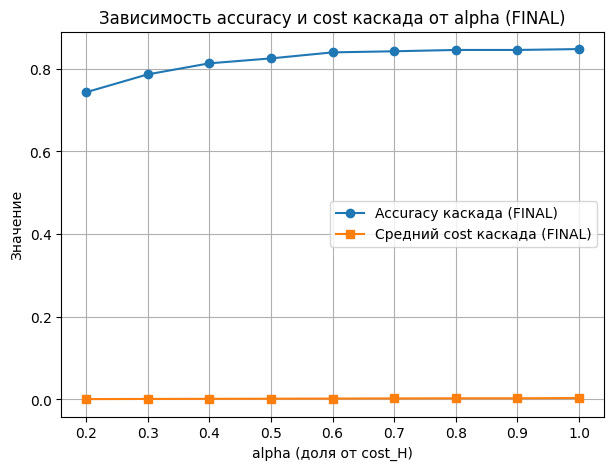

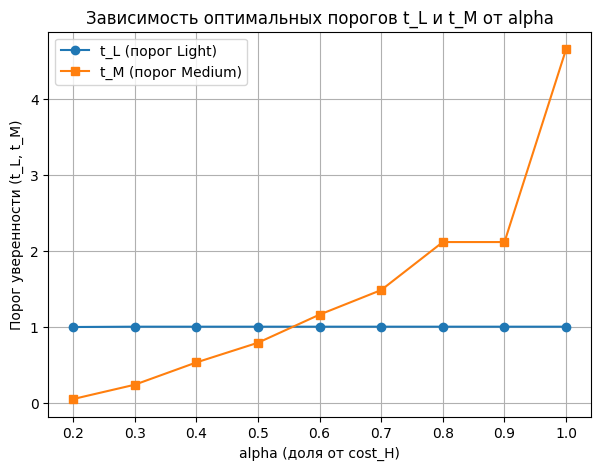

In [12]:
# ======================================================
# 8. Перебор alpha = 0, 0.1, ..., 1.0 и оценка каскадов на FINAL
# ======================================================

alpha_list = np.linspace(0.0, 1.0, 11)  # [0.0, 0.1, ..., 1.0]

records = []

for alpha_val in alpha_list:
    budget = alpha_val * cost_H_val
    df_feasible = df[df["cost"] <= budget]

    if len(df_feasible) == 0:
        # нет ни одной комбинации порогов, удовлетворяющих бюджету
        records.append({
            "alpha": alpha_val,
            "has_solution": False,
            "t_L": np.nan,
            "t_M": np.nan,
            "acc_val": np.nan,
            "cost_val": np.nan,
            "acc_final": np.nan,
            "cost_final": np.nan,
            "pL_final": np.nan,
            "pM_final": np.nan,
            "pH_final": np.nan,
        })
        continue

    # Лучший по accuracy на VAL при данном alpha
    best_row = df_feasible.loc[df_feasible["acc"].idxmax()]
    t_L_best = best_row["t_L"]
    t_M_best = best_row["t_M"]

    # Accuracy и cost каскада на FINAL при этих порогах
    acc_fin, cost_fin, pL_fin, pM_fin, pH_fin = eval_cascade_LMH(
        conf_L_final, conf_M_final,
        y_L_final, y_M_final, y_H_final, y_final,
        cost_L_final, cost_M_final, cost_H_final,
        t_L_best, t_M_best
    )

    records.append({
        "alpha": alpha_val,
        "has_solution": True,
        "t_L": t_L_best,
        "t_M": t_M_best,
        "acc_val": best_row["acc"],
        "cost_val": best_row["cost"],
        "acc_final": acc_fin,
        "cost_final": cost_fin,
        "pL_final": pL_fin,
        "pM_final": pM_fin,
        "pH_final": pH_fin,
    })

df_alpha = pd.DataFrame(records)
print("\nРезультаты по alpha:")
print(df_alpha)


# ======================================================
# 9. График accuracy и cost каскада на FINAL в зависимости от alpha
# ======================================================

# Оставим только те alpha, где решение нашлось
mask = df_alpha["has_solution"]
df_alpha_ok = df_alpha[mask]

plt.figure(figsize=(7, 5))
plt.plot(df_alpha_ok["alpha"], df_alpha_ok["acc_final"],
         marker="o", label="Accuracy каскада (FINAL)")
plt.plot(df_alpha_ok["alpha"], df_alpha_ok["cost_final"],
         marker="s", label="Средний cost каскада (FINAL)")

plt.xlabel("alpha (доля от cost_H)")
plt.ylabel("Значение")
plt.title("Зависимость accuracy и cost каскада от alpha (FINAL)")
plt.grid(True)
plt.legend()
plt.show()


# ======================================================
# 10. График порогов t_L и t_M в зависимости от alpha
# ======================================================

plt.figure(figsize=(7, 5))
plt.plot(df_alpha_ok["alpha"], df_alpha_ok["t_L"],
         marker="o", label="t_L (порог Light)")
plt.plot(df_alpha_ok["alpha"], df_alpha_ok["t_M"],
         marker="s", label="t_M (порог Medium)")

plt.xlabel("alpha (доля от cost_H)")
plt.ylabel("Порог уверенности (t_L, t_M)")
plt.title("Зависимость оптимальных порогов t_L и t_M от alpha")
plt.grid(True)
plt.legend()
plt.show()


# ГРАФИКИ и анализы моделей

Base accuracies:  L=0.6654, M=0.7496, H=0.8492
Base costs     :  L=0.000310, M=0.000316, H=0.003328

Всего смесей: 5151


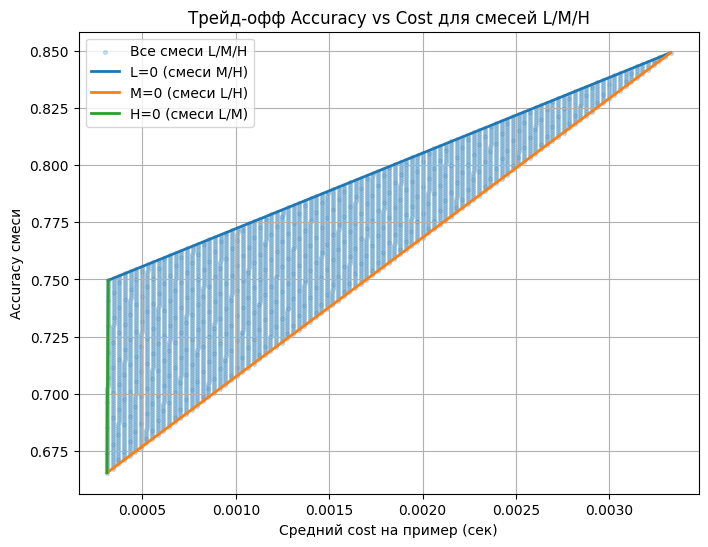

In [14]:
# ============================================================
# ГРИД ПО ВСЕМ 5151 СМЕСЯМ L/M/H (L+M+H=100) И ГРАФИКИ:
#  - общий ACC vs COST
#  - отдельные линии при L=0, M=0, H=0
# ============================================================
# Требуется, чтобы уже были в памяти:
#   y_meta_true, yL, yM, yH  (одинаковой длины)
#   costL, costM, costH  (средний cost на пример для каждой модели)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Базовые accuracies трёх моделей
y_true = np.asarray(y_final)
y_L    = np.asarray(y_L_final)
y_M    = np.asarray(y_M_final)
y_H    = np.asarray(y_H_final)

acc_L = (y_L == y_true).mean()
acc_M = (y_M == y_true).mean()
acc_H = (y_H == y_true).mean()

costL = cost_L_final # Corrected: use cost_L_final
costM = cost_M_final # Corrected: use cost_M_final
costH = cost_H_final # Corrected: use cost_H_final

print(f"Base accuracies:  L={acc_L:.4f}, M={acc_M:.4f}, H={acc_H:.4f}")
print(f"Base costs     :  L={costL:.6f}, M={costM:.6f}, H={costH:.6f}")

# 2) Строим все смеси L/M/H, такие что L+M+H=100
weights = []   # в процентах
for L in range(0, 101):
    for M in range(0, 101 - L):
        H = 100 - L - M
        weights.append((L, M, H))

weights = np.array(weights)          # shape (5151, 3)
w_frac  = weights / 100.0            # в долях (0..1)

# 3) Для каждой смеси считаем теоретический accuracy и cost
acc_vec  = np.array([acc_L,  acc_M,  acc_H])
cost_vec = np.array([costL, costM, costH])

acc_mix  = w_frac @ acc_vec          # (5151,)
cost_mix = w_frac @ cost_vec         # (5151,)

df_mix = pd.DataFrame({
    "L": weights[:, 0],
    "M": weights[:, 1],
    "H": weights[:, 2],
    "acc": acc_mix,
    "cost": cost_mix,
})

print("\nВсего смесей:", len(df_mix))

# 4) Линии L=0, M=0, H=0 (границы симплекса)
df_L0 = df_mix[df_mix["L"] == 0].sort_values("cost")
df_M0 = df_mix[df_mix["M"] == 0].sort_values("cost")
df_H0 = df_mix[df_mix["H"] == 0].sort_values("cost")

# 5) График ACC vs COST для всех смесей + отдельные линии
plt.figure(figsize=(8, 6))
plt.scatter(df_mix["cost"], df_mix["acc"], s=8, alpha=0.2, label="Все смеси L/M/H")

# линии по границам симплекса
plt.plot(df_L0["cost"], df_L0["acc"], linewidth=2, label="L=0 (смеси M/H)")
plt.plot(df_M0["cost"], df_M0["acc"], linewidth=2, label="M=0 (смеси L/H)")
plt.plot(df_H0["cost"], df_H0["acc"], linewidth=2, label="H=0 (смеси L/M)")

plt.xlabel("Средний cost на пример (сек)")
plt.ylabel("Accuracy смеси")
plt.title("Трейд-офф Accuracy vs Cost для смесей L/M/H")
plt.legend()
plt.grid(True)
plt.show()

Base accuracies:  L=0.6654, M=0.7496, H=0.8492
Base costs     :  L=0.000310, M=0.000316, H=0.003328

Всего комбинаций: 5151


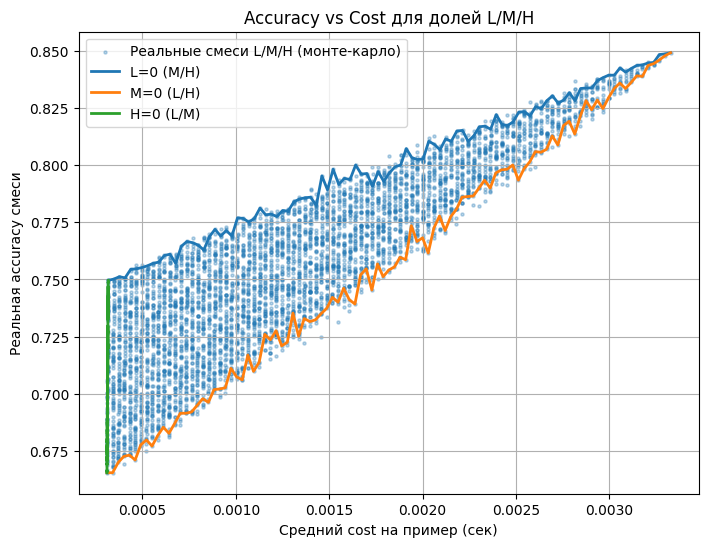

In [16]:
# ============================================================
# РЕАЛЬНАЯ ПРОВЕРКА СМЕСЕЙ L/M/H НА КАЖДОМ ПРИМЕРЕ (MONTE CARLO)
# ============================================================
# Требуется:
#   y_meta_true, yL, yM, yH  (одинаковой длины)
#   costL, costM, costH
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

rng = np.random.RandomState(42)
n_runs = 1  # можно увеличить до 3–5 для усреднения

y_true = np.asarray(y_final)
y_L    = np.asarray(y_L_final)
y_M    = np.asarray(y_M_final)
y_H    = np.asarray(y_H_final)

N = len(y_true)

acc_L = accuracy_score(y_true, y_L)
acc_M = accuracy_score(y_true, y_M)
acc_H = accuracy_score(y_true, y_H)

print(f"Base accuracies:  L={acc_L:.4f}, M={acc_M:.4f}, H={acc_H:.4f}")
print(f"Base costs     :  L={cost_L_final:.6f}, M={cost_M_final:.6f}, H={cost_H_final:.6f}")

rows = []

# перебор всех смесей L,M,H (в процентах), L+M+H=100
for Lp in range(0, 101):
    for Mp in range(0, 101 - Lp):
        Hp = 100 - Lp - Mp

        wL = Lp / 100.0
        wM = Mp / 100.0
        wH = Hp / 100.0

        # теоретический cost (он всё равно линеен)
        cost_mix = wL * cost_L_final + wM * cost_M_final + wH * cost_H_final

        acc_runs = []

        for _ in range(n_runs):
            # для каждого объекта выбираем модель по заданным долям
            choices = rng.choice(
                [0, 1, 2],
                size=N,
                p=[wL, wM, wH]
            )

            y_pred = np.empty_like(y_true)
            y_pred[choices == 0] = y_L[choices == 0]
            y_pred[choices == 1] = y_M[choices == 1]
            y_pred[choices == 2] = y_H[choices == 2]

            acc_runs.append(accuracy_score(y_true, y_pred))

        acc_real = np.mean(acc_runs)

        rows.append({
            "L": Lp,
            "M": Mp,
            "H": Hp,
            "wL": wL,
            "wM": wM,
            "wH": wH,
            "acc_real": acc_real,
            "cost_mix": cost_mix
        })

df_real = pd.DataFrame(rows)
print("\nВсего комбинаций:", len(df_real))

# границы симплекса для наглядности
df_L0 = df_real[df_real["L"] == 0].sort_values("cost_mix")
df_M0 = df_real[df_real["M"] == 0].sort_values("cost_mix")
df_H0 = df_real[df_real["H"] == 0].sort_values("cost_mix")

plt.figure(figsize=(8, 6))
plt.scatter(df_real["cost_mix"], df_real["acc_real"],
            s=5, alpha=0.3, label="Реальные смеси L/M/H (монте-карло)")

plt.plot(df_L0["cost_mix"], df_L0["acc_real"], linewidth=2, label="L=0 (M/H)")
plt.plot(df_M0["cost_mix"], df_M0["acc_real"], linewidth=2, label="M=0 (L/H)")
plt.plot(df_H0["cost_mix"], df_H0["acc_real"], linewidth=2, label="H=0 (L/M)")

plt.xlabel("Средний cost на пример (сек)")
plt.ylabel("Реальная accuracy смеси")
plt.title("Accuracy vs Cost для долей L/M/H")
plt.legend()
plt.grid(True)
plt.show()

## Максимальная точность

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score

y_true = np.asarray(y_final)
y_L    = np.asarray(y_L_final)
y_M    = np.asarray(y_M_final)
y_H    = np.asarray(y_H_final)

# Базовые точности
acc_L = accuracy_score(y_true, y_L)
acc_M = accuracy_score(y_true, y_M)
acc_H = accuracy_score(y_true, y_H)

print(f"Base accuracies: L={acc_L:.4f}, M={acc_M:.4f}, H={acc_H:.4f}")

# Оракул, который может выбирать ЛУЧШУЮ из трёх для каждого примера
correct_any = (y_L == y_true) | (y_M == y_true) | (y_H == y_true)
acc_oracle_3 = correct_any.mean()

print(f"\nМаксимально возможная accuracy (идеальный роутер L/M/H): {acc_oracle_3:.4f}")

Base accuracies: L=0.6654, M=0.7496, H=0.8492

Максимально возможная accuracy (идеальный роутер L/M/H): 0.8850


## средняя уверенность = средний margin на train

In [19]:
import numpy as np



# Light
_, dec_L_train, _ = get_preds_dec_cost(pipe_L, X_train_texts)
conf_L_train = margin_conf(dec_L_train)
mean_conf_L = conf_L_train.mean()

# Medium
_, dec_M_train, _ = get_preds_dec_cost(pipe_M_bow, X_train_texts)
conf_M_train = margin_conf(dec_M_train)
mean_conf_M = conf_M_train.mean()

# High
_, dec_H_train, _ = get_preds_dec_cost(pipe_H, X_train_texts)
conf_H_train = margin_conf(dec_H_train)
mean_conf_H = conf_H_train.mean()

print("Средняя уверенность на TRAIN:")
print(f"  Light : {mean_conf_L:.4f}")
print(f"  Medium: {mean_conf_M:.4f}")
print(f"  High  : {mean_conf_H:.4f}")


Средняя уверенность на TRAIN:
  Light : 0.9214
  Medium: 3.8884
  High  : 1.9724


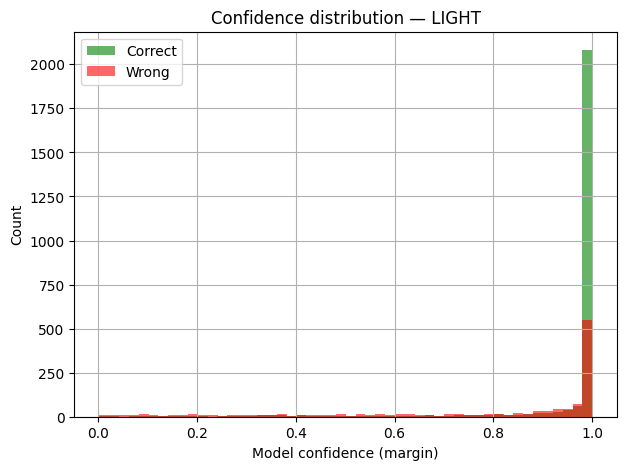

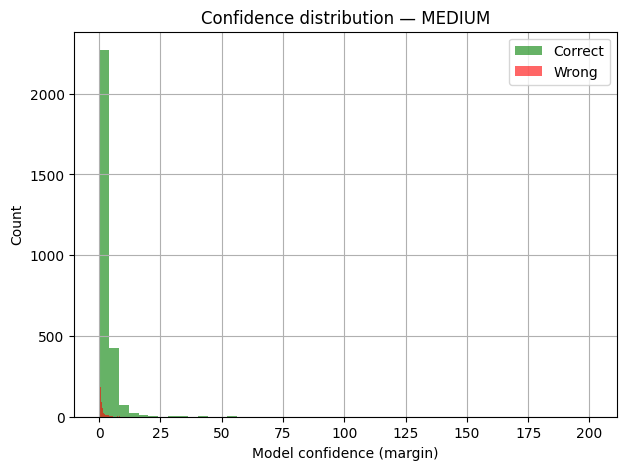

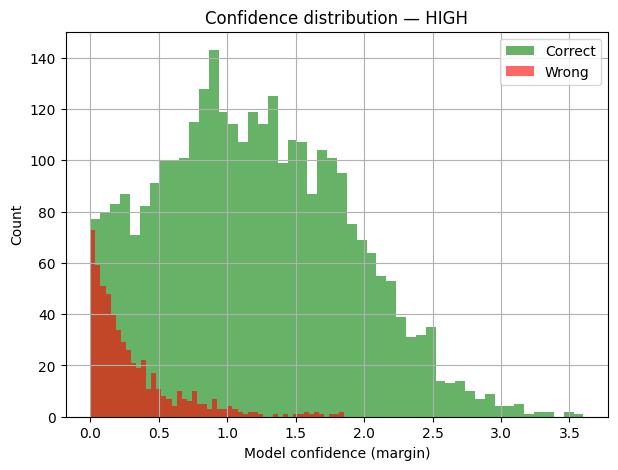

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_conf_distribution(name, y_true, y_pred, dec):
    conf = margin_conf(dec)  # твоя функция margin_conf

    correct_mask = (y_true == y_pred)
    conf_correct = conf[correct_mask]
    conf_wrong   = conf[~correct_mask]

    plt.figure(figsize=(7,5))
    plt.hist(conf_correct, bins=50, alpha=0.6, label="Correct", color="green")
    plt.hist(conf_wrong,   bins=50, alpha=0.6, label="Wrong",   color="red")

    plt.title(f"Confidence distribution — {name}")
    plt.xlabel("Model confidence (margin)")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()


# Light
plot_conf_distribution("LIGHT", y_final, y_L_final, dec_L_final)

# Medium
plot_conf_distribution("MEDIUM", y_final, y_M_final, dec_M_final)

# High
plot_conf_distribution("HIGH", y_final, y_H_final, dec_H_final)
